# LeetCode #131: Palindrome Partitioning

https://leetcode.com/problems/palindrome-partitioning/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Brute force (generate all partitions, filter) | O(n·2^n) | O(n·2^n) | Stores all intermediate results |
| **Backtracking + palindrome check** | **O(n·2^n)** | **O(n)** | **Optimal — prune non-palindromes early** |

## Understanding the Method

Backtracking explores all ways to partition the string:
- At each position, try every possible next substring
- Only recurse if that substring is a palindrome (pruning)
- When we reach the end of the string, the current path is complete

## Constraints

- `1 <= s.length <= 16`
- `s` consists of lowercase English letters.

## Solutions

### C#

In [ ]:
public class Solution {
    IList<IList<string>> result = new List<IList<string>>();
    List<string> current = new List<string>();
    public IList<IList<string>> Partition(string s) {
        Backtrack(s, 0);
        return result;
    }
    void Backtrack(string s, int start) {
        if (start == s.Length) { result.Add(new List<string>(current)); return; }
        for (int end = start + 1; end <= s.Length; end++) {
            string sub = s.Substring(start, end - start);
            if (IsPal(sub)) {
                current.Add(sub);
                Backtrack(s, end);
                current.RemoveAt(current.Count - 1);
            }
        }
    }
    bool IsPal(string s) {
        int l = 0, r = s.Length - 1;
        while (l < r) { if (s[l++] != s[r--]) return false; }
        return true;
    }
}

### Python

In [ ]:
class Solution:
    def partition(self, s: str) -> list[list[str]]:
        result = []
        def backtrack(start, path):
            if start == len(s):
                result.append(path[:])
                return
            for end in range(start + 1, len(s) + 1):
                sub = s[start:end]
                if sub == sub[::-1]:
                    path.append(sub)
                    backtrack(end, path)
                    path.pop()
        backtrack(0, [])
        return result

### Go

In [ ]:
func partition(s string) [][]string {
    result := [][]string{}
    var backtrack func(start int, path []string)
    backtrack = func(start int, path []string) {
        if start == len(s) {
            cp := make([]string, len(path))
            copy(cp, path)
            result = append(result, cp)
            return
        }
        for end := start + 1; end <= len(s); end++ {
            sub := s[start:end]
            if isPal(sub) {
                backtrack(end, append(path, sub))
            }
        }
    }
    backtrack(0, []string{})
    return result
}
func isPal(s string) bool {
    for l, r := 0, len(s)-1; l < r; l, r = l+1, r-1 {
        if s[l] != s[r] { return false }
    }
    return true
}

### Rust

In [ ]:
impl Solution {
    pub fn partition(s: String) -> Vec<Vec<String>> {
        let s: Vec<char> = s.chars().collect();
        let mut result = vec![];
        let mut path = vec![];
        Self::backtrack(&s, 0, &mut path, &mut result);
        result
    }
    fn backtrack(s: &[char], start: usize, path: &mut Vec<String>, result: &mut Vec<Vec<String>>) {
        if start == s.len() { result.push(path.clone()); return; }
        for end in (start+1)..=s.len() {
            let sub: Vec<char> = s[start..end].to_vec();
            if sub.iter().eq(sub.iter().rev()) {
                path.push(sub.iter().collect());
                Self::backtrack(s, end, path, result);
                path.pop();
            }
        }
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `s = "aab"`  
Backtracking from index 0: "a" is palindrome $\to$ recurse. "aa" is palindrome $\to$ recurse. "aab" is NOT a palindrome $\to$ pruned. Two valid partitions found: $["a","a","b"]$ and $["aa","b"]$.  
WHY tricky: Shows how pruning skips non-palindrome substrings early — "ab" and "aab" are never explored further.  
**Output:** `[["a","a","b"],["aa","b"]]`

### 2. Slightly Complex
**Input:** `s = "abacaba"`  
Rich in nested palindromes: "aba" (indices 0-2), "abacaba" (entire string), "aca" (indices 2-4), "bacab" (indices 1-5). The entire string is itself a palindrome, yielding $["abacaba"]$. Other partitions include $["aba","c","aba"]$ and $["a","bacab","a"]$.  
WHY tricky: Nested palindromes ("aba" inside "abacaba") create many overlapping valid partitions. Tests that backtracking explores all branches.  
**Output:** Multiple partitions including `["abacaba"]`, `["aba","c","aba"]`, etc.

### 3. Edge Case: Time Factor
**Input:** `s = "aaaaaaaaaaaaaaaa"` (16 a's — maximum length)  
Every substring is a palindrome. Every possible partition is valid: $2^{n-1} = 2^{15} = 32{,}768$ partitions. No pruning is possible since all characters are identical.  
WHY tricky: $2^{15} = 32{,}768$ is the absolute worst case. Time complexity $O(n \cdot 2^n)$ is unavoidable here. Tests that the solution handles exponential output.  
**Output:** 32,768 valid partitions

### 4. Edge Case: Space Factor
**Input:** `s = "abcdefghijklmnop"` (16 distinct characters)  
No multi-character palindromes exist. Only single-character splits are valid. Exactly ONE partition: $["a","b",...,"p"]$. Recursion depth reaches $n = 16$.  
WHY tricky: Maximum recursion depth with minimal output. Every multi-char substring fails palindrome check, so pruning is maximally effective. Stack space $O(n)$.  
**Output:** `[["a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p"]]`

### 5. Almost-Impossible but Plausible
**Input:** `s = "aaaaaaaabbbbbbbb"` (8 a's + 8 b's, length 16)  
Within the a-block, every substring is a palindrome. Same for the b-block. But cross-boundary substrings like "ab" are NOT palindromes. Valid partitions must split exactly at the a-b boundary: $2^7 \times 2^7 = 16{,}384$ total.  
WHY tricky: The a-b boundary creates a mandatory partition point, cutting search space from $2^{15}$ to $2^7 \times 2^7$. Tests that pruning at the boundary works correctly.  
**Output:** 16,384 valid partitions — boundary forces split

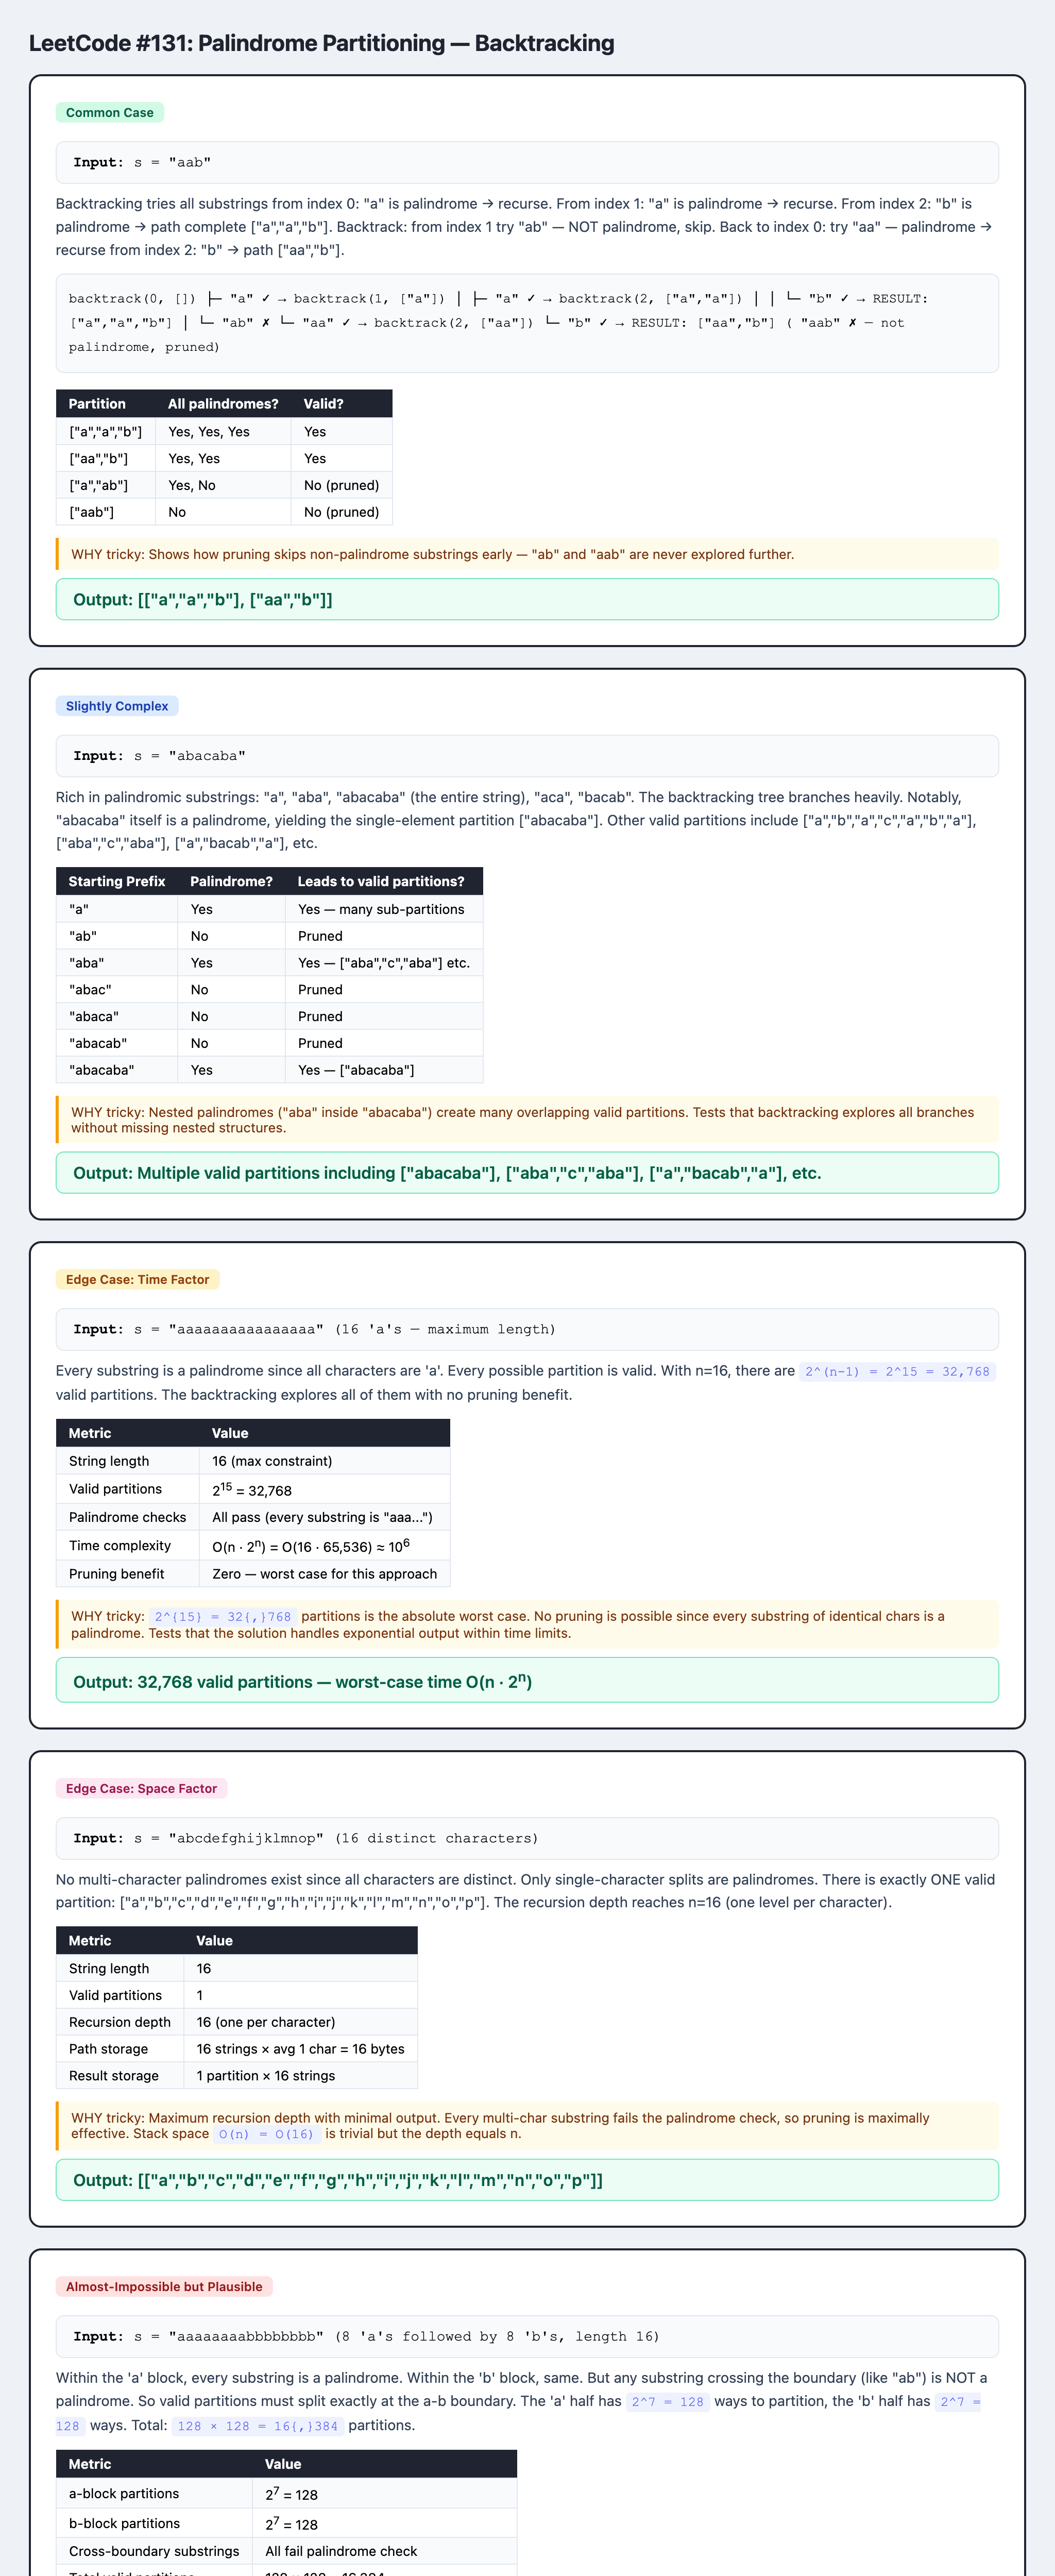